<div style="
border:3px solid #0f172a;
background-color:#f8fafc;
padding:18px;
font-size:17px;
font-family:'Trebuchet MS', sans-serif;
color:#0f172a;
border-radius:12px;
">

<span style="font-size:22px; font-weight:bold; color:#7c3aed;">
🏢 MARKET SEGMENTATION IN INSURANCE - UNSUPERVISED LEARNING 
</span>
<br><br>

<h2 style="font-family:Montserrat,sans-serif;color:#007A74;text-transform:uppercase;">STEP - 1 - PREPROCESSING</h2>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\shree\Downloads\DATA SCIENCE\UNSUPERVISED LEARNING.ipynb\Customer Data.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [2]:
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [3]:
df["MINIMUM_PAYMENTS"]=df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"]=df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [4]:
df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["CUST_ID"]=le.fit_transform(df["CUST_ID"])
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,312.343947,0.000000,6
8947,8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


<span style="color:GREEN; font-size:30px; font-weight:bold;">
📊 VISUALIZATION – UNSUPERVISED LEARNING
</span>

COUNT PLOT

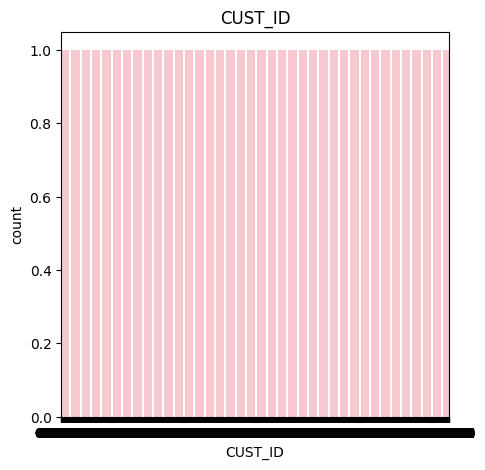

In [3]:
plt.figure(figsize=(5,5))
sns.countplot(x="CUST_ID",data=df,color="pink")
plt.title("CUST_ID")
plt.show()

BOX PLOT

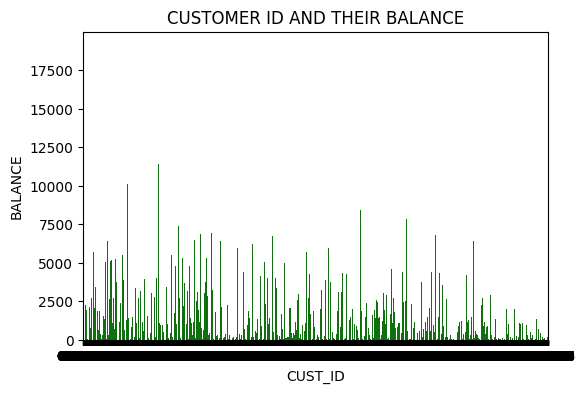

In [5]:
plt.figure(figsize=(6,4))
sns.barplot(x="CUST_ID",y="BALANCE",data=df,color="green")
plt.title("CUSTOMER ID AND THEIR BALANCE")
plt.show()

<span style="color:YELLOW; font-weight:bold; border:1px solid #1dd8c872; padding:5px;">
Most customers have low account balances, with only a few showing very high balances (tall spikes).
</span>

KDE PLOT

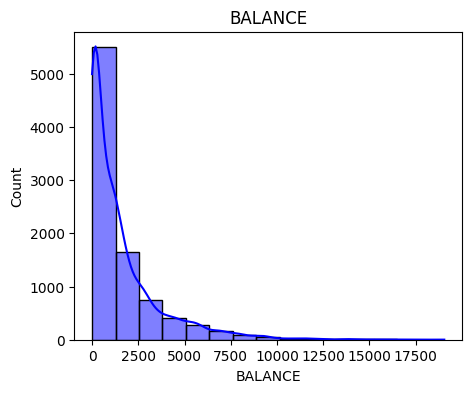

In [11]:
plt.figure(figsize=(5,4))
sns.histplot(x="BALANCE",bins=15,kde="True",data=df,color="blue")
plt.title("BALANCE")
plt.show()

<span style="color:VIOLET; font-weight:bold; padding:5px;">
The BALANCE distribution is highly right-skewed, with most customers holding low balances concentrated near zero.

A small number of customers maintain very high balances, creating a long right tail and visible outliers
</span>

BOX PLOT

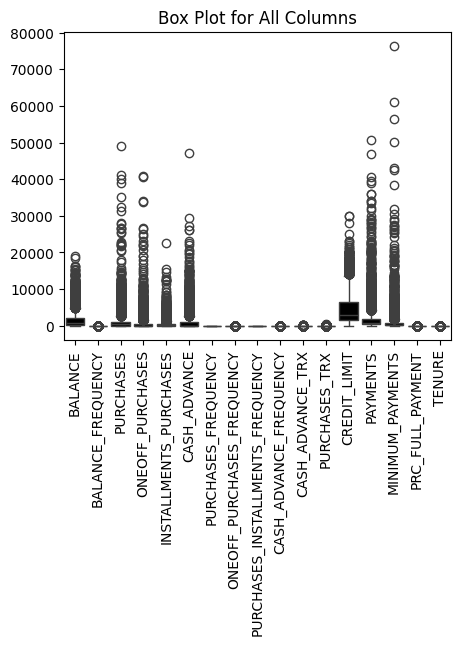

In [9]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, color="black")
plt.title("Box Plot for All Columns")
plt.xticks(rotation=90)
plt.show()

<span style="color:GREEN; font-weight:bold; padding:5px;">
Most monetary variables (BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS) are highly right-skewed with many extreme outliers, indicating large variation in customer spending behavior.

Frequency and tenure-related features are tightly clustered with fewer outliers, suggesting more stable and consistent usage patterns across customers.
</span>

SCATTER PLOT

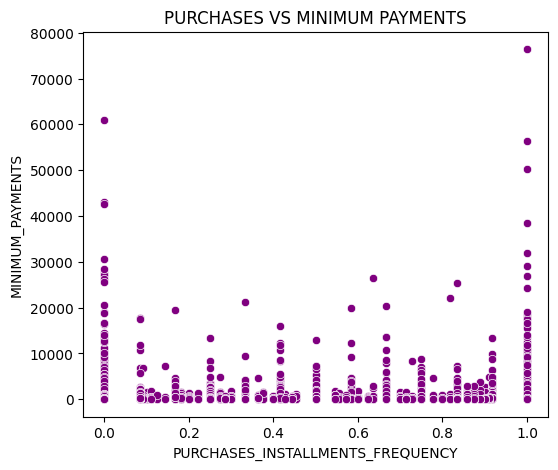

In [10]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="PURCHASES_INSTALLMENTS_FREQUENCY",y="MINIMUM_PAYMENTS",data=df,color="purple")
plt.title("PURCHASES VS MINIMUM PAYMENTS")
plt.show()

<span style="color:BLUE; font-weight:bold; padding:5px;">
There is no strong linear relationship between purchase installment frequency and minimum payments, as points are widely scattered.
</span>

HEAT MAP

In [12]:
numerical=df[["BALANCE","PURCHASES_FREQUENCY","PRC_FULL_PAYMENT","TENURE"]].corr()
numerical

,BALANCE,PURCHASES_FREQUENCY,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,-0.077944,-0.318959,0.072692
PURCHASES_FREQUENCY,-0.077944,1.000000,0.305802,0.061506
PRC_FULL_PAYMENT,-0.318959,0.305802,1.000000,-0.016486
TENURE,0.072692,0.061506,-0.016486,1.000000


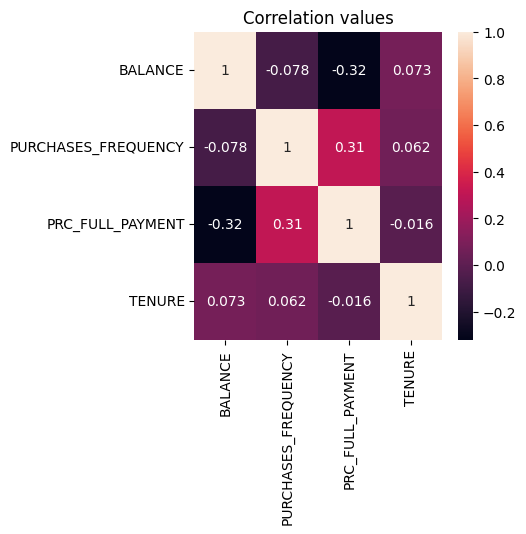

In [13]:
numerical
plt.figure(figsize=(4,4))
sns.heatmap(numerical,annot=True)
plt.title("Correlation values")
plt.show()

<span style="color:VIOLET; font-weight:bold; padding:5px;">
Balance shows a moderate negative correlation with full payment percentage, meaning higher balances tend to pay less in full.
</span>


<h1 style="font-family:Arial Black,sans-serif;font-size:20px;color:WHITE;text-transform:uppercase;">K-MEANS CLUSTERING</h1>


In [17]:
cash=df["CASH_ADVANCE"].values
credit_usage=df["CREDIT_LIMIT"].values                
x=np.array(list(zip(cash,credit_usage)))
x

array([[   0.      , 1000.      ],
       [6442.945483, 7000.      ],
       [   0.      , 7500.      ],
       ...,
       [   0.      , 1000.      ],
       [  36.558778,  500.      ],
       [ 127.040008, 1200.      ]], shape=(8950, 2))

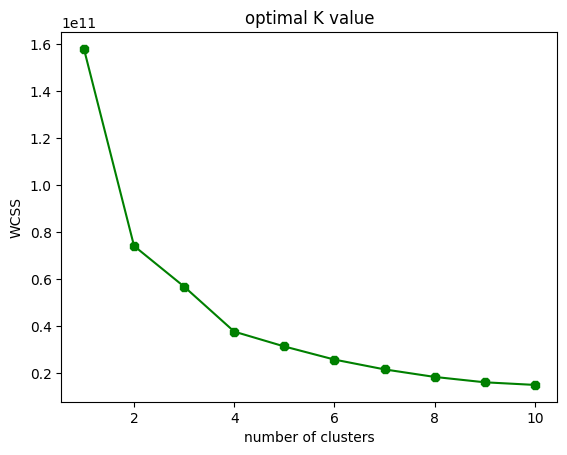

In [18]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    knn=KMeans(n_clusters=i,random_state=0)
    knn.fit(x)
    wcss.append(knn.inertia_)
plt.plot(range(1,11),wcss,color="green",marker="8")
plt.title("optimal K value")
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [19]:
model=KMeans(n_clusters=3,random_state=0)
y_means=model.fit_predict(x)
y_means

array([1, 2, 0, ..., 1, 1, 1], shape=(8950,), dtype=int32)

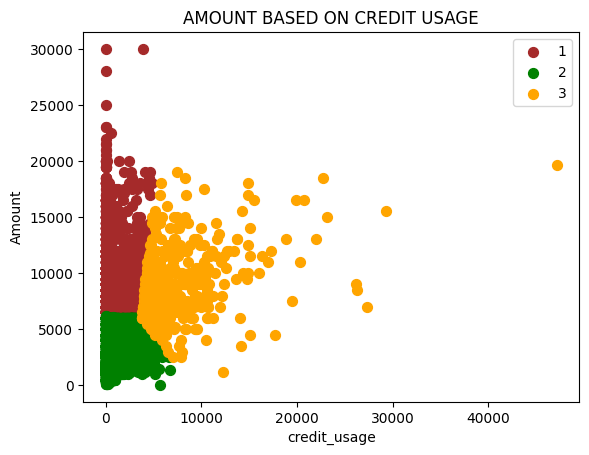

In [24]:
plt.scatter(x[y_means==0,0],x[y_means==0,1],s=50,c="brown",label="1")
plt.scatter(x[y_means==1,0],x[y_means==1,1],s=50,c="green",label="2")
plt.scatter(x[y_means==2,0],x[y_means==2,1],s=50,c="orange",label="3")
plt.title("AMOUNT BASED ON CREDIT USAGE")
plt.xlabel("credit_usage")
plt.ylabel("Amount")
plt.legend()

<div style="
border:3px dashed #7c2d12;
background-color:#fff1f2;
padding:16px;
font-size:17px;
font-family:Georgia, serif;
color:#7c2d12;
border-radius:10px;
">

<strong style="font-size:19px; color:#9f1239;">Clusters:</strong><br>The K-Means clustering groups customers based on credit usage patterns into low, moderate, and high usage segments for effective decision-making
<span style="color:#6d28d9; font-weight:bold;">
<br><br>
